# Classification Metrics

##what is Confusion Matrix

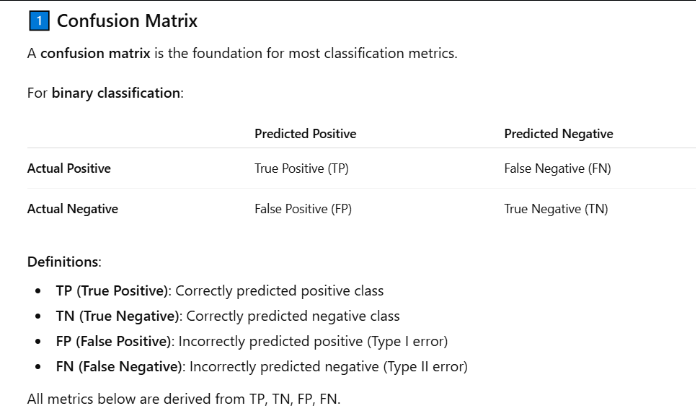

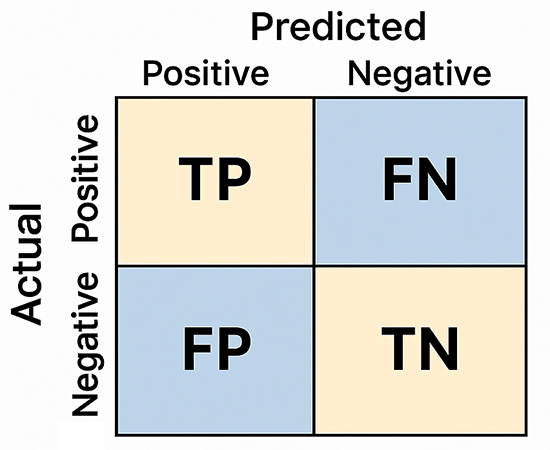

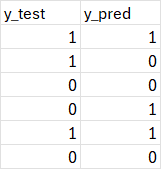

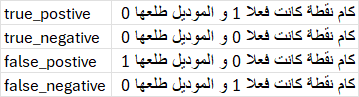

#  I use Confucion Matrix to get the 4 Rules (Accuracy)

## 1- Accuracy

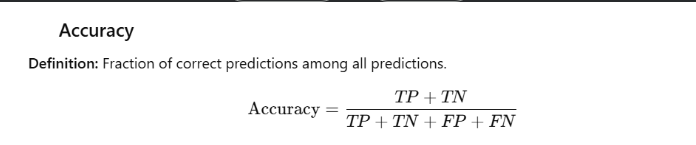

# 2- Precision

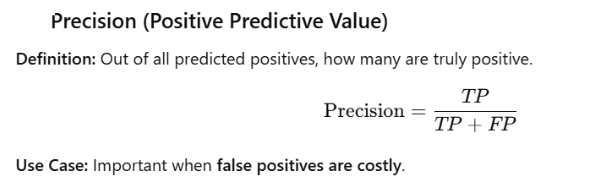

# 3- Recall

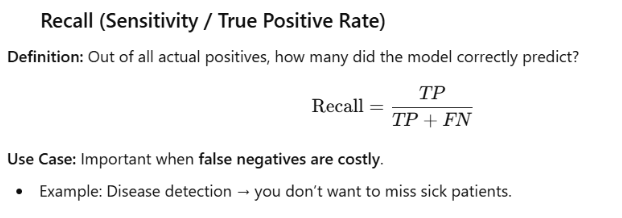

# 4- F1-Score

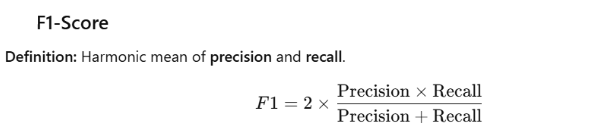

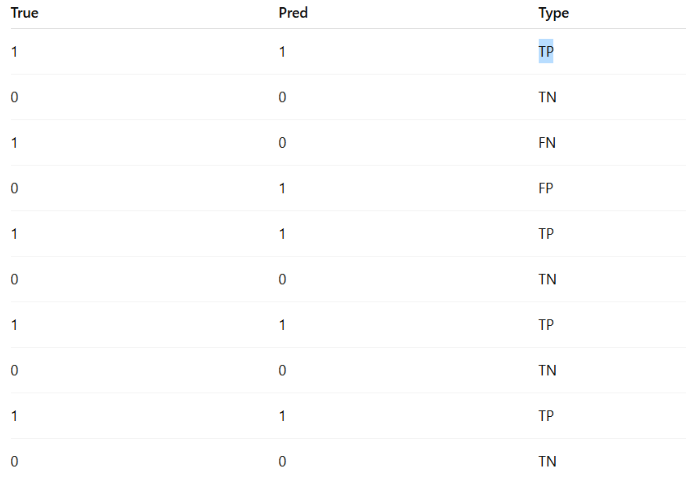

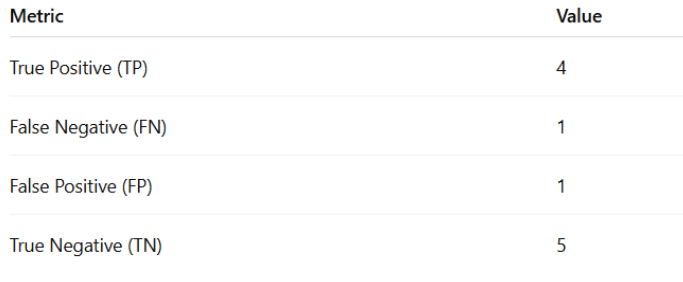

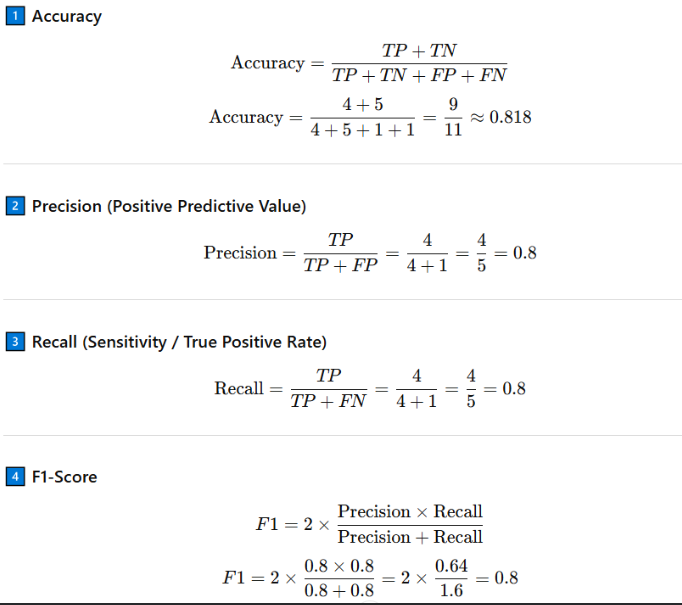

#Example

In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score # new

# Load the real dataset
df=pd.read_csv("/content/breast_cancer.csv")

# Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train a classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Extract metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMetrics:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")


Confusion Matrix:
[[39  3]
 [ 2 70]]

Metrics:
Accuracy:  0.956
Precision: 0.959
Recall:    0.972
F1 Score:  0.966


#Why not to Try to Write your own Code ?

In [4]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Load the real dataset
df=pd.read_csv("/content/breast_cancer.csv")



# Split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# ---- Calculate metrics manually ----
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1-Score
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# ---- Create a table=DF to display ----
metrics_table = pd.DataFrame({
    "Metric": ["TP", "FN", "FP", "TN", "Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [TP, FN, FP, TN, round(accuracy,3), round(precision,3), round(recall,3), round(f1,3)]
})

metrics_table

,Metric,Value
0,TP,70.000
1,FN,2.000
2,FP,3.000
3,TN,39.000
4,Accuracy,0.956
5,Precision,0.959
6,Recall,0.972
7,F1-Score,0.966
